## Zero Shot GeoCIR using CLIP

In [7]:
import sys

sys.path.append("..")
from transformers import AutoTokenizer, AutoModel, AutoProcessor
import polars as pl
import os
import torch
from src.utils import read_index
from PIL import Image
import faiss
import numpy as np
import random
import matplotlib.pyplot as plt
import json

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model_name = "openai/clip-vit-large-patch14"
base_img_path = "../../datasets/google-landmark/index-img"
topk = 100

In [2]:
clip_processor = AutoProcessor.from_pretrained(clip_model_name)
clip_tokenizer = AutoTokenizer.from_pretrained(clip_model_name)
clip_model = AutoModel.from_pretrained(clip_model_name).to(device)

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
index, meta = read_index("../index/clip_gld")
index.hnsw.efSearch = 128
meta = meta["metadata"]

In [6]:
df_ref = pl.read_csv(
    # "../../datasets/mp16-reason/mp16-reason-train-annot-filtered.csv"
    "../../datasets/google-landmark/index_ref_predicted_siglip_filtered.csv"
)
df_ref.head()

row_idx,landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error,supercategory,hierarchical_label,natural_or_human_made,rg_name,rg_admin1,rg_admin2,country_code,country,continent,subregion,id,category,confidence
i64,i64,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,f64
0,36227,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",38.892778,-77.023056,null,"""archive building""",null,null,"""Washington, D.C.""","""Washington, D.C.""","""""","""US""","""United States""","""America""","""Northern America""","""2eaf1281b9715e91""","""railway_station""",0.019987
1,39704,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",16.284983,121.091865,null,"""church building""","""church""","""human-made""","""Malasin""","""Cagayan Valley""","""Province of Nueva Vizcaya""","""PH""","""Philippines""","""Asia""","""South-eastern Asia""","""d3b1332814fc7b80""","""temple_shrine""",0.01273
2,40249,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",41.8309,-71.41496,null,"""capitol building""",null,null,"""Providence""","""Rhode Island""","""Providence County""","""US""","""United States""","""America""","""Northern America""","""581544d78bb3feb4""","""railway_station""",0.000355
3,84013,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",40.406714,-3.71162,null,"""city gate""","""gate""","""human-made""","""Madrid""","""Madrid""","""Provincia de Madrid""","""ES""","""Spain""","""Europe""","""Southern Europe""","""72f1048035d11f8e""","""arch_gate""",0.802222
4,41641,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",54.083,13.9162,null,"""pier""","""harbor""","""human-made""","""Ostseebad Zinnowitz""","""Mecklenburg-Vorpommern""","""""","""DE""","""Germany""","""Europe""","""Western Europe""","""ece2023f36ad9863""","""harbor_pier""",0.692005


In [9]:
test_set = json.loads(open("../../datasets/geocir-triplet/test.v1.json", "r").read())
test_set = test_set["data"]

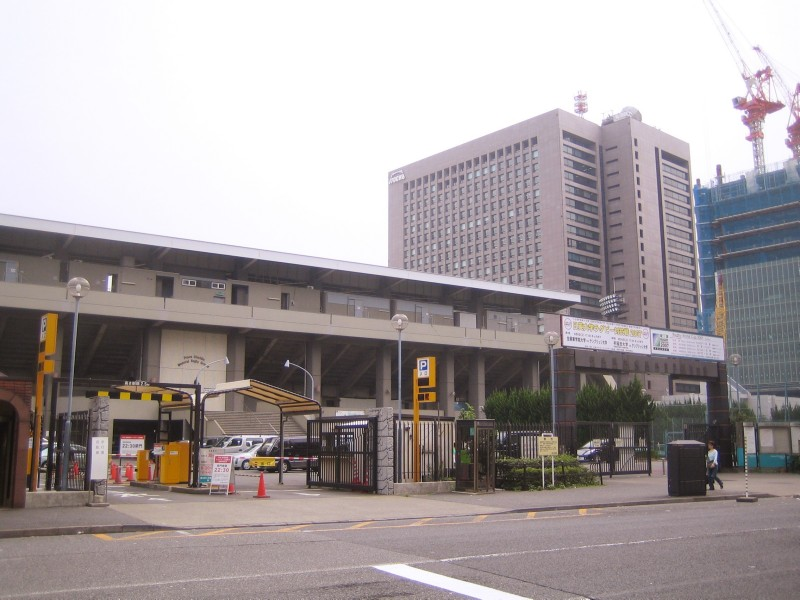

In [575]:
japan_landmark = df_ref.filter(pl.col("country_code") == "JP").to_dicts()
rand_id = random.choice(range(len(japan_landmark)))
Image.open(os.path.join(base_img_path, f"{japan_landmark[rand_id]['id']}.jpg"))

In [576]:
japan_landmark[rand_id]

{'landmark_id': 79502,
 'input_url': 'http://commons.wikimedia.org/wiki/Category:Chichibunomiya_Rugby_Stadium',
 'resolved_url': 'https://commons.wikimedia.org/wiki/Category:Chichibunomiya_Rugby_Stadium',
 'geohack_url': 'https://geohack.toolforge.org/geohack.php?pagename=Category:Chichibunomiya_Rugby_Stadium&params=35.672603_N_139.718169_E_globe:Earth_&language=en',
 'latitude': 35.672603,
 'longitude': 139.718169,
 'error': None,
 'supercategory': 'rugby union venue',
 'hierarchical_label': 'sports venue',
 'natural_or_human_made': 'human-made',
 'rg_name': 'Tokyo',
 'rg_admin1': 'Tokyo',
 'rg_admin2': '',
 'country_code': 'JP',
 'country': 'Japan',
 'continent': 'Asia',
 'subregion': 'East Asia',
 'id': 'ac41431e28057bcb'}

In [577]:
img_query = Image.open(os.path.join(base_img_path, japan_landmark[rand_id]["id"] + ".jpg"))
text_query = "but located in Europe"

img_processed = clip_processor(img_query, return_tensors="pt")
text_processed = clip_tokenizer(
    text_query,
    padding="max_length",
    truncation=True,
    max_length=77,
    return_tensors="pt",
)
query_inputs = {**img_processed, **text_processed}

with torch.no_grad():
    query_inputs = {k: v.to(device) for k, v in query_inputs.items()}
    out = clip_model(**query_inputs)
    img_emb = out.image_embeds.cpu().numpy()
    text_emb = out.text_embeds.cpu().numpy()

faiss.normalize_L2(img_emb)
faiss.normalize_L2(text_emb)

In [578]:
img_sim, img_ind = index.search(img_emb, topk)
text_sim, text_ind = index.search(text_emb, topk)

In [579]:
merged_ind = np.concat([img_ind, text_ind], axis=1).reshape(-1)
merged_embs = np.zeros((len(merged_ind), index.d))
for i, ind in enumerate(merged_ind):
    merged_embs[i] = index.reconstruct(int(ind))

In [580]:
s_style = merged_embs @ img_emb.reshape(-1)
s_geo = merged_embs @ text_emb.reshape(-1)

In [581]:
s_final = s_style * s_geo
s_final_harris = (s_style * s_geo) - 0.1 * np.power(s_style + s_geo, 2)

s_final_ind = [merged_ind[i].item() for i in np.argsort(s_final)]
s_final_harris_ind = [merged_ind[i].item() for i in np.argsort(s_final_harris)]

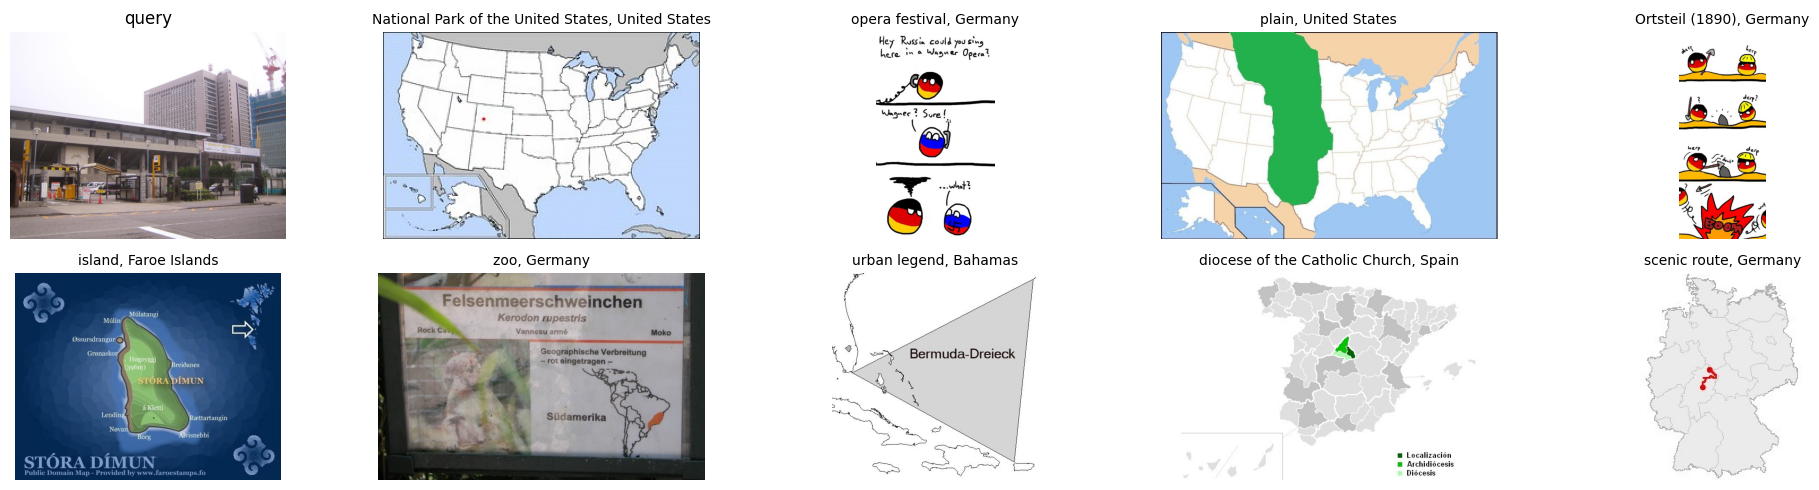

In [582]:
import os
from PIL import Image
import matplotlib.pyplot as plt

items = df_ref[s_final_ind[:10]].to_dicts()

fig, axes = plt.subplots(2, 5, figsize=(20, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i == 0:
        ax.imshow(img_query)
        ax.set_title("query")
    else:
        img_path = os.path.join(base_img_path, items[i]["id"] + ".jpg")
        ax.imshow(Image.open(img_path))
        ax.set_title(f"{items[i]['supercategory']}, {items[i]['country']}", fontsize=10)
    ax.axis("off")

# hide any unused axes (safe if <10 items)
for ax in axes[len(items):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


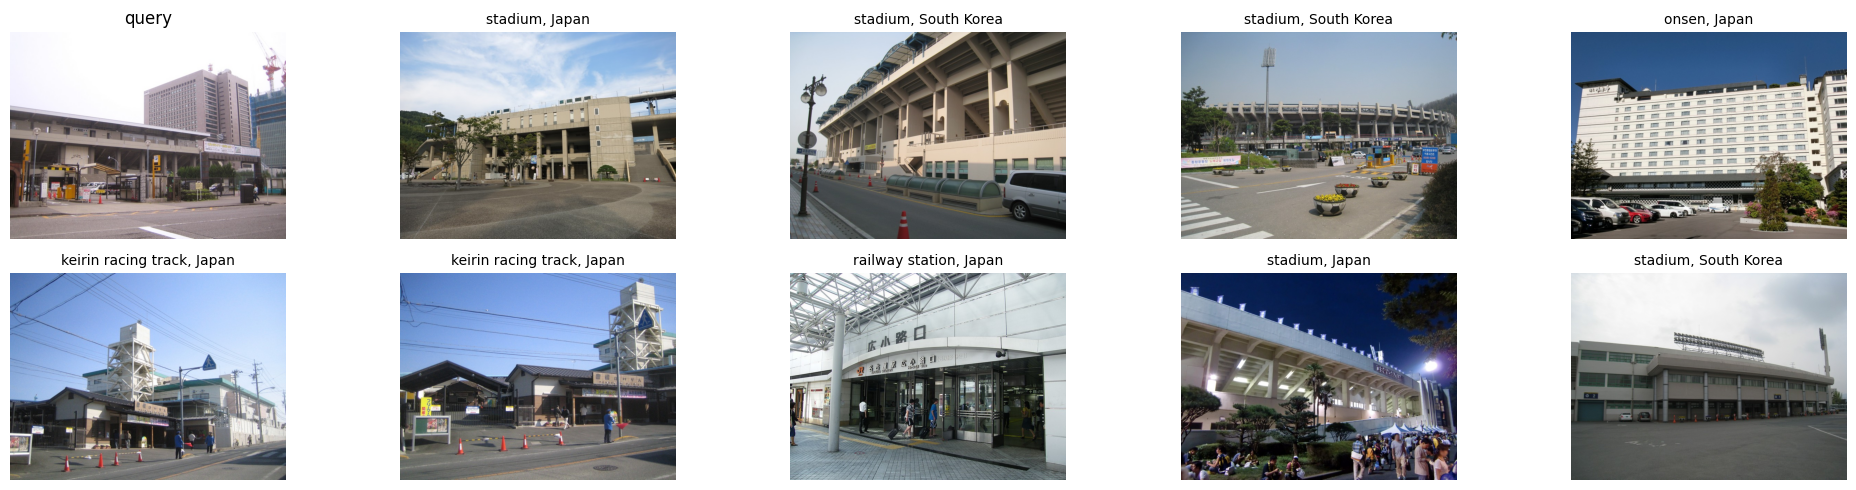

In [583]:
items = df_ref[s_final_harris_ind[:10]].to_dicts()

fig, axes = plt.subplots(2, 5, figsize=(20, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i == 0:
        ax.imshow(img_query)
        ax.set_title("query")
    else:
        img_path = os.path.join(base_img_path, items[i]["id"] + ".jpg")
        ax.imshow(Image.open(img_path))
        ax.set_title(f"{items[i]['supercategory']}, {items[i]['country']}", fontsize=10)
    ax.axis("off")

# hide any unused axes (safe if <10 items)
for ax in axes[len(items):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


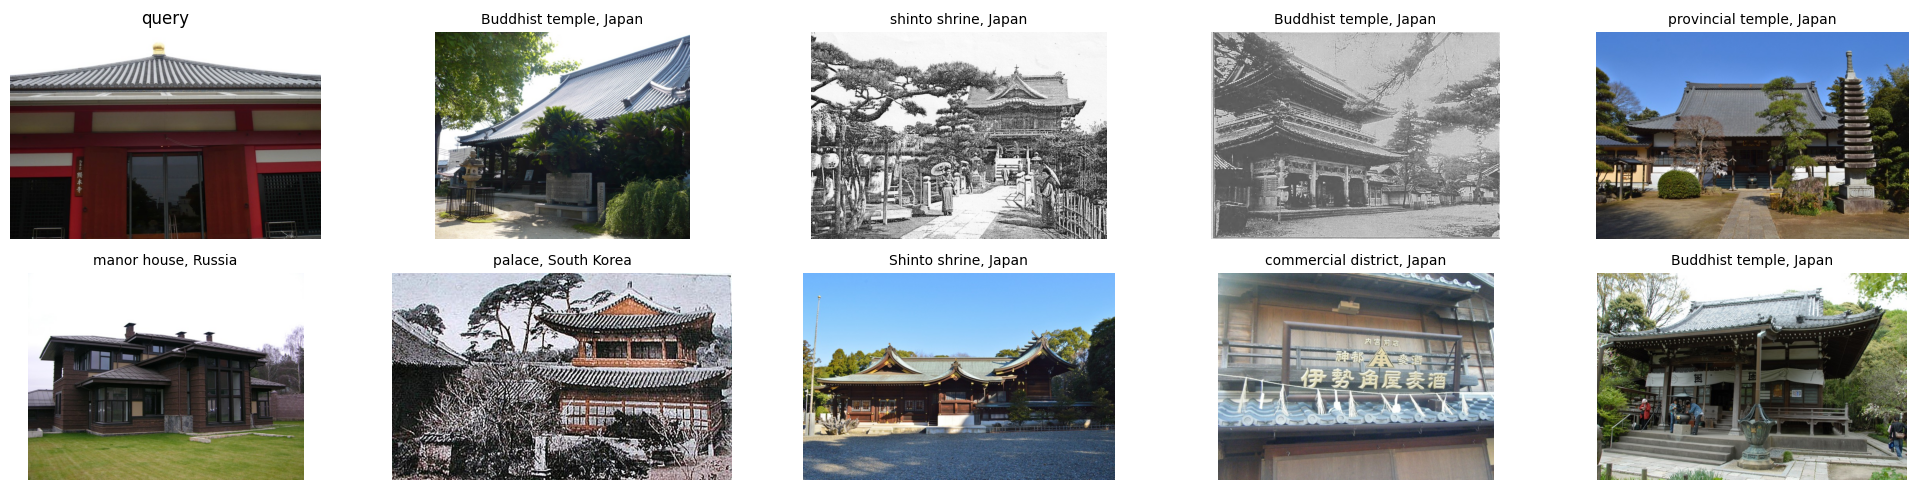

In [565]:
import os
from PIL import Image
import matplotlib.pyplot as plt

items = df_ref[s_final_ind[95:110]].to_dicts()

fig, axes = plt.subplots(2, 5, figsize=(20, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i == 0:
        ax.imshow(img_query)
        ax.set_title("query")
    else:
        img_path = os.path.join(base_img_path, items[i]["id"] + ".jpg")
        ax.imshow(Image.open(img_path))
        ax.set_title(f"{items[i]['supercategory']}, {items[i]['country']}", fontsize=10)
    ax.axis("off")

# hide any unused axes (safe if <10 items)
for ax in axes[len(items):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
